<a href="https://colab.research.google.com/github/karolalonso70-dev/Estad-sticaVerano2026/blob/main/Copy_of_Practica01U3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 01 para series de tiempo

Para esta práctica, se utilizará la librería `yfinance`, la cual permite obtener datos históricos de mercados financieros directamente desde Yahoo Finance. Esta herramienta es de uso gratuito y no requiere el uso de claves de acceso (API keys), lo que la hace especialmente conveniente para fines educativos.

Los datos obtenidos mediante `yfinance` corresponden a información real del mercado financiero. Sin embargo, es importante considerar que esta herramienta no constituye una fuente oficial de datos, por lo que puede presentar limitaciones en cuanto a disponibilidad, consistencia o actualización. Para fines académicos y de análisis exploratorio, estos datos son adecuados; no obstante, para aplicaciones profesionales o decisiones financieras, se recomienda el uso de fuentes oficiales o servicios especializados.

Adicionalmente, `yfinance` no es una API oficial, por lo que en ocasiones puede presentar fallas temporales en la descarga de datos.

Los principales argumentos que requiere yfinance para realizar la descarga son:

+ `tickers`: Los tickers son identificadores únicos de activos financieros (por ejemplo, acciones) en los mercados. Por ejemplo, `AAPL` corresponde a Apple, `TSLA` a Tesla y `MSFT` a Microsoft. Si quieres inspeccionar tickers [pulsa aquí](https://www.nasdaq.com/market-activity/stocks/screener) y se te abrirá un catálogo de diversas multinacionales.
+ `start`: Fecha de inicio para la descarga de datos en formato `YYYY-mm-dd` que significa: cuatro dígitos para el año (`YYYY`), dos dígitos para el mes (`mm`) y dos dígitos para el día (`dd`) en ese orden.
+ `end`: Fecha de fin para la descarga de datos siguiendo también un formato `YYYY-mm-dd`.
+ `interval`: Define la frecuencia de los datos. Por ejemplo, `"1d"` indica datos diarios, `"1wk"` semanales y `"1mo"` mensuales.
+ `group_by`: Define la forma en que se organizan las columnas cuando se descargan datos de uno o varios tickers. Por ejemplo, `group_by="column"` organiza la información por tipo de variable (Open, High, Low, Close, etc.), mientras que `group_by="ticker"` agrupa primero por activo financiero.
+ `auto_adjust`: Si se establece en `True`, los precios se ajustan automáticamente considerando dividendos y divisiones de acciones. Si es `False`, se mantienen los valores originales.
+ `actions`: Permite incluir información adicional como dividendos y divisiones de acciones cuando se establece en `True`.
+ `progress`: Controla si se muestra o no una barra de progreso durante la descarga.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

# Link para inspeccionar tickers:
# https://www.nasdaq.com/market-activity/stocks/screener

# Obtener datos de acciones
df = yf.download(
    tickers="AAPL",          # AAPL: Apple, TSLA: Tesla, MSFT: Microsoft, etc.
    start="2024-01-01",      # Fecha de inicio
    end="2026-04-01",        # Fecha de fin
    interval="1d",           # Intervalo de tiempo: 1 día
    group_by="column",       # Forma estándar de organizar las columnas
    auto_adjust=False,       # False conserva columnas como Close y Adj Close
    actions=False,           # True incluiría dividendos y divisiones de acciones
    progress=False           # Evita mostrar barra de progreso
)

# Verificar si la descarga fue exitosa
if df.empty:
    raise ValueError(
        "No se descargaron datos. Verifica que el ticker sea correcto "
        "o intenta nuevamente más tarde."
    )

# Paso 1: Mover 'Date' del índice a columna regular
df = df.reset_index()

# Paso 2: Aplanar columnas si vienen como MultiIndex
# Esto puede ocurrir dependiendo de la versión de yfinance/pandas.
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [
        "_".join([str(valor) for valor in columna if valor != ""]).strip()
        for columna in df.columns
    ]

# Reemplazar espacios por _
df.columns = [i.replace(" ", "_") for i in df.columns]

# Paso 3:
#######################################################
## En caso de que no se requiera la hora

# Convertir la columna 'Date' a tipo datetime
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

df

,Date,Adj_Close_AAPL,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL
0,2024-01-02,183.562180,185.639999,188.440002,183.889999,187.149994,82488700
1,2024-01-03,182.187759,184.250000,185.880005,183.429993,184.220001,58414500
2,2024-01-04,179.873947,181.910004,183.089996,180.880005,182.149994,71983600
3,2024-01-05,179.152100,181.179993,182.759995,180.169998,181.990005,62379700
4,2024-01-08,183.483078,185.559998,185.600006,181.500000,182.089996,59144500
...,...,...,...,...,...,...,...
558,2026-03-25,252.387466,252.619995,255.000000,251.600006,254.100006,28476700
559,2026-03-26,252.657227,252.889999,257.000000,250.770004,252.119995,41796700
560,2026-03-27,248.570984,248.800003,255.490005,248.070007,253.899994,47900000
561,2026-03-30,246.402985,246.630005,250.869995,245.509995,250.070007,39446200


Una vez extraida la información, tenemos un DataFrame con las siguientes variables:

+ `Date`: Fecha correspondiente a cada registro de la serie de tiempo.
+ `Open_AAPL`: Precio de apertura de la acción al inicio de la jornada.
+ `High_AAPL`: Precio máximo alcanzado por la acción durante el intervalo de tiempo seleccionado.
+ `Low_AAPL`: Precio mínimo registrado durante el intervalo de tiempo seleccionado.
+ `Close_AAPL`: Precio de cierre de la acción al final del intervalo de tiempo seleccionado.
+ `Adj_Close_AAPL`: Precio de cierre ajustado, el cual incorpora efectos de dividendos y divisiones de acciones, proporcionando una medida más consistente para análisis históricos.
+ `Volume_AAPL`: Número total de acciones negociadas durante el día (volumen de transacciones).

En las series de tiempo `x` siempre es la variable temporal, en esta caso `Date`, mientras que `y` puede ser cualquiera de las restantes, dependiendo de lo que se esté analizando. En este caso recomiendo usar `Adj_Close_APPL` debido a que es la que incorpora más información.

Primero se debe revisar el DataFrame para asegurarnos de que las variables son del tipo adecuado (sin variables tipo `object`).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 563 entries, 0 to 562
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            563 non-null    datetime64[ns]
 1   Adj_Close_AAPL  563 non-null    float64       
 2   Close_AAPL      563 non-null    float64       
 3   High_AAPL       563 non-null    float64       
 4   Low_AAPL        563 non-null    float64       
 5   Open_AAPL       563 non-null    float64       
 6   Volume_AAPL     563 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 30.9 KB


Ahora se declara `x` y `y`.

In [ ]:
x = df["Date"]
y = df['Adj_Close_AAPL']

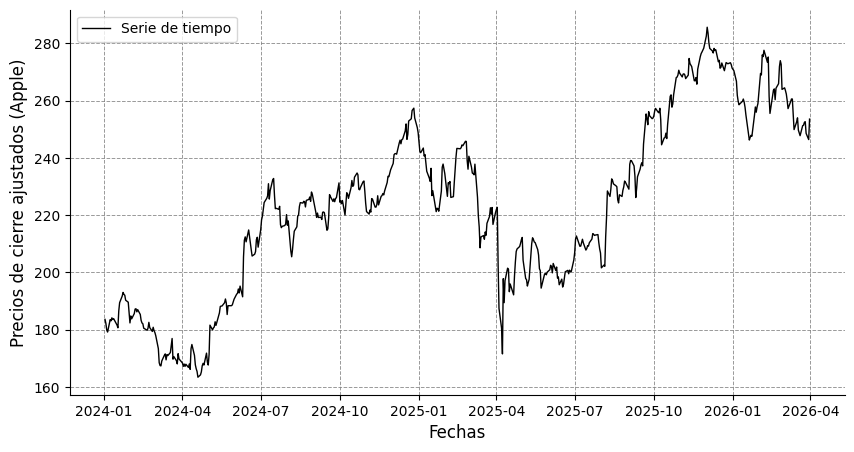

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, y,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie de tiempo'
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Precios de cierre ajustados (Apple)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)



## Métodos de promedios móviles

**Ejercicio 1**: Aplica una media móvil simple (SMA) a la serie de tiempo. Prueba con distintos tamaños de ventana (`window`) y selecciona uno que consideres adecuado. Justifica tu elección con base en el comportamiento observado en la serie.

Ten en cuenta que la serie de tiempo no incluye sábados ni domingos; por lo tanto, aproximadamente:

+ 5 observaciones corresponden a una semana
+ 21 observaciones a un mes
+ 252 observaciones a un año

Una vez termines, borra estas instrucciones y redacta tus observaciones.


In [ ]:
# Promedio Móvil Simple
df['Adj_Close_AAPL_SMA'] = df['Adj_Close_AAPL'].rolling(window=21).mean()

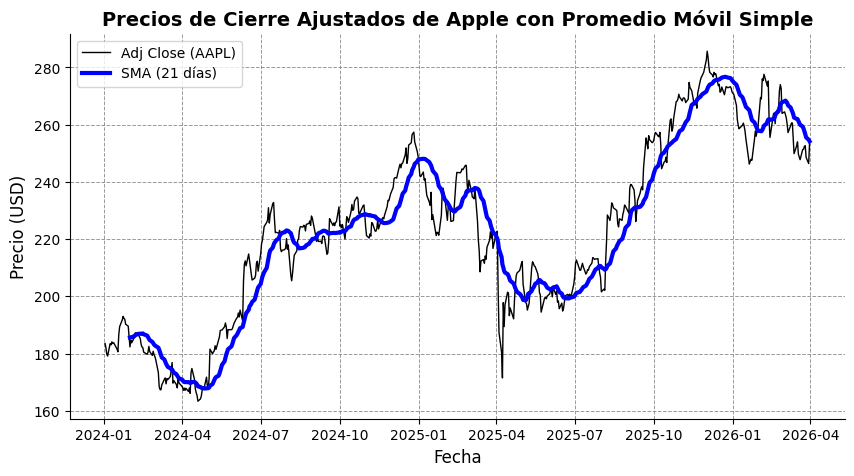

In [ ]:
# @title
import matplotlib.pyplot as plt

# Redefine x and y for the current DataFrame (Apple stock data)
x = df["Date"]
y = df['Adj_Close_AAPL']

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, y,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Adj Close (AAPL)'
)

# --- Gráfico de línea ---
plt.plot(
    x, df["Adj_Close_AAPL_SMA"],
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='SMA (21 días)'
)

# --- Título ---
plt.title(
    'Precios de Cierre Ajustados de Apple con Promedio Móvil Simple',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fecha',
    fontsize=12
)

plt.ylabel(
    'Precio (USD)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

plt.show()

**Observaciones**: Elegí usar una ventana de 21 días porque equivale más o menos a un mes de trabajo en la bolsa. Esto ayuda a limpiar los altibajos diarios del precio sin alejarse tanto de lo que pasa en la realidad. Si usas menos días se ve mucho desorden, y si usas demasiados, el gráfico tarda mucho en mostrar los cambios de dirección.

## Método de suavisación exponencial

**Ejercicio 2**: Aplica una suavización exponencial simple (SES) a la serie de tiempo. Prueba con distintos valores del parámetro de suavizamiento (por ejemplo, mediante span o alpha) y selecciona uno que consideres adecuado. Justifica tu elección con base en el comportamiento observado en la serie.

Ten en cuenta que la serie de tiempo no incluye sábados ni domingos; por lo tanto, aproximadamente:

+ 5 observaciones corresponden a una semana
+ 21 observaciones a un mes
+ 252 observaciones a un año

Una vez termines, borra estas instrucciones y redacta tus observaciones.

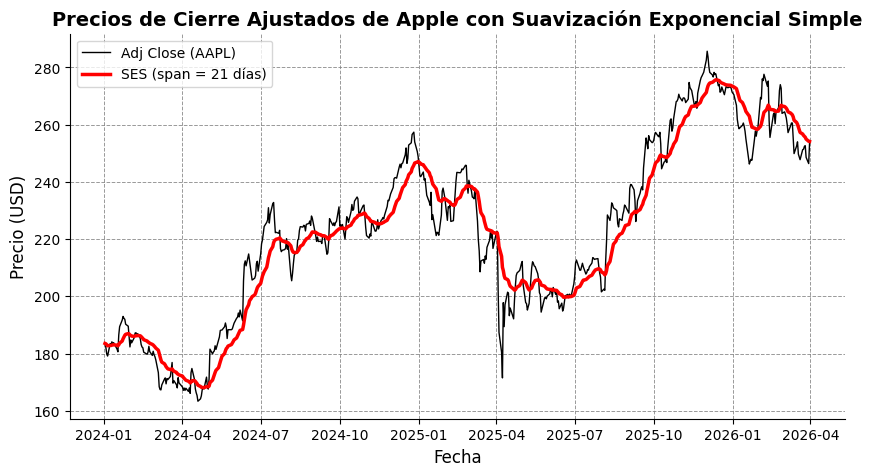

In [ ]:

# Calculamos la suavización exponencial simple con span = 21 días
df['Adj_Close_AAPL_SES'] = df['Adj_Close_AAPL'].ewm(span=21, adjust=False).mean()

# Configuración del gráfico
plt.figure(figsize=(10, 5), dpi=100)

# Gráfico de la serie real
plt.plot(
    x, y,
    color='black',
    linewidth=1.0,
    linestyle='-',
    marker='o',
    markersize=0,
    label='Adj Close (AAPL)'
)

# Gráfico de la curva SES
plt.plot(
    x, df['Adj_Close_AAPL_SES'],
    color='red',
    linewidth=2.5,
    linestyle='-',
    marker='o',
    markersize=0,
    label='SES (span = 21 días)'
)

# Título y etiquetas
plt.title('Precios de Cierre Ajustados de Apple con Suavización Exponencial Simple', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)

# Formato de ejes y márgenes
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.margins(x=0.05, y=0.05)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

# Cuadrícula y leyenda
plt.grid(visible=True, linestyle='--', linewidth=0.7, alpha=0.8, color="gray")
plt.legend(fontsize=10, loc='best', frameon=True)

plt.show()

se aplicó una suavización exponencial con un parámetro de 21 días. Este ajuste le da más peso a los precios más recientes, lo que permite que la curva responda más rápido a las subidas y caídas de la acción que un promedio simple.

**Ejercicio 3**: Observando las curvas por SMA y SES, señala las ventajas y desventajas que puedes observar en ambos gráficos.

Una vez termines, borra estas instrucciones y redacta tus observaciones.

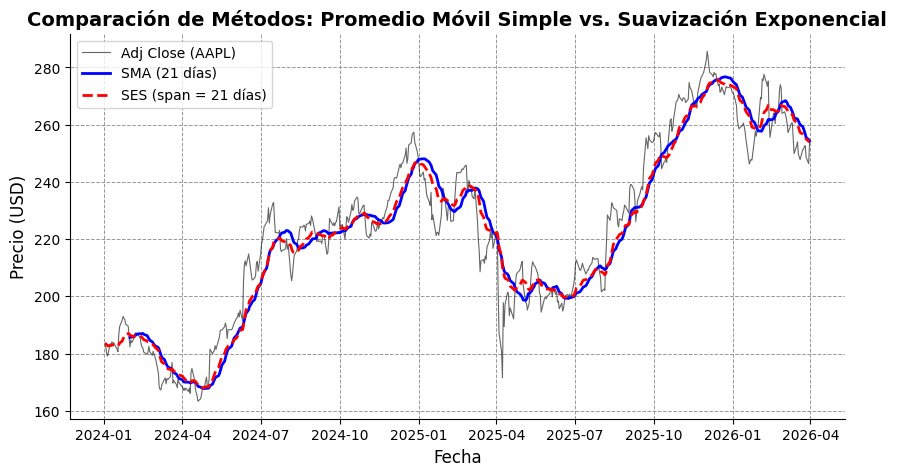

In [ ]:

plt.figure(figsize=(10, 5), dpi=100)

# Serie real
plt.plot(
    x, y,
    color='black',
    linewidth=0.8,
    linestyle='-',
    alpha=0.6,
    label='Adj Close (AAPL)'
)

# Curva SMA (21 días)
plt.plot(
    x, df['Adj_Close_AAPL_SMA'],
    color='blue',
    linewidth=2.0,
    linestyle='-',
    label='SMA (21 días)'
)

# Curva SES (span = 21 días)
plt.plot(
    x, df['Adj_Close_AAPL_SES'],
    color='red',
    linewidth=2.0,
    linestyle='--',
    label='SES (span = 21 días)'
)

# Título y etiquetas
plt.title('Comparación de Métodos: Promedio Móvil Simple vs. Suavización Exponencial', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)

# Formato de ejes y márgenes
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.margins(x=0.05, y=0.05)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

# Cuadrícula y leyenda
plt.grid(visible=True, linestyle='--', linewidth=0.7, alpha=0.8, color="gray")
plt.legend(fontsize=10, loc='best', frameon=True)

plt.show()

SMA: Su ventaja es que es muy fácil de entender y marca bien la tendencia general; su desventaja es que va atrasada respecto al precio real.
SES: Su ventaja es que reacciona de volada cuando el precio cambia de dirección porque le importan más los datos recientes; su desventaja es que al estar tan pegada al precio puede llegar a confundir ruido pasajero con un cambio real de tendencia.

## Tendencias no lineales

**Ejercicio 4**: Realiza una regresión polinomial de grado 2. Usa series de Fourier para extraer la estacionalidad y calcular el ruido de medición. Apóyate en los gráficos correspondientes y analiza las longitudes de onda para establecer si existe estacionalidad. Ten en cuenta que la serie de tiempo no incluye sábados ni domingos; por lo tanto, aproximadamente:

+ 5 observaciones corresponden a una semana
+ 21 observaciones a un mes
+ 252 observaciones a un año

Una vez termines, borra estas instrucciones y redacta tus observaciones.

In [ ]:
from numpy.polynomial.polynomial import Polynomial
X = x.map(pd.Timestamp.timestamp)
grado = 2
modelo = Polynomial.fit(X, y, deg = grado)
df['tendencia_polinomial'] = modelo(X)
df['ruido_polinomial'] = y - df['tendencia_polinomial']

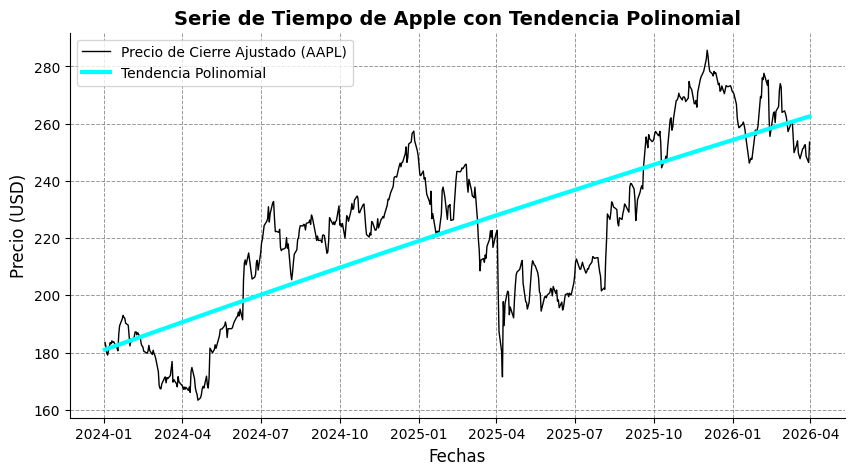

In [ ]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, y,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Precio de Cierre Ajustado (AAPL)'
)

# --- Gráfico de línea ---
plt.plot(
    x, df["tendencia_polinomial"],
    color='cyan',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Tendencia Polinomial'
)

# --- Título ---
plt.title(
    'Serie de Tiempo de Apple con Tendencia Polinomial',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Precio (USD)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

**Observaciones**: La línea del modelo muestra que el precio ha ido subiendo con el tiempo. De todos modos, en acciones como Apple no hay fechas o meses exactos donde el precio siempre haga lo mismo de forma repetitiva. El precio se mueve más por lo que pasa en el mercado que por el calendario

## Análisis de los componentes de la serie

**Ejercicio 5**: Apóyate de los gráficos correspondientes para analizar cada uno de los componentes de la serie por separado. Comenta lo que se puede observar de cada componente, si crees que se pudo aproximar bien o no, y por qué.

Una vez termines, borra estas instrucciones y redacta tus observaciones.

In [ ]:
serie_real = y
# serie_aproximada = df["tendencia_polinomial"] + df["estacionalidad_polinomial"] + df["ruido_polinomial"]
# La línea de arriba está comentada porque 'estacionalidad_polinomial' aún no ha sido calculada.


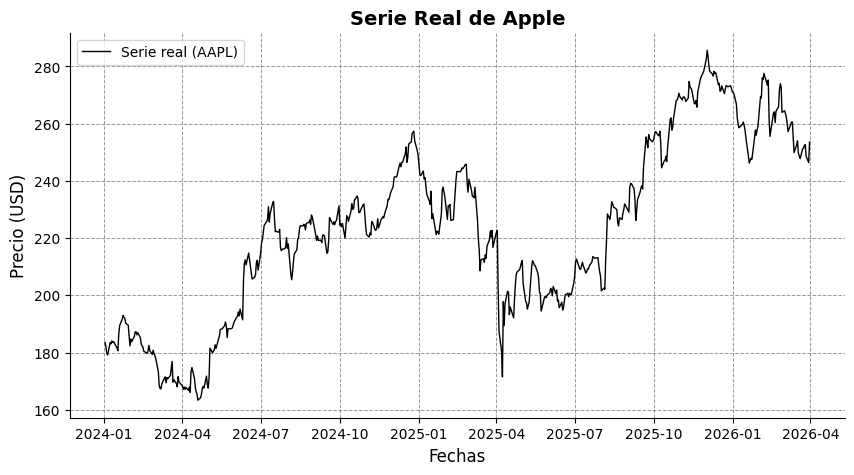

In [ ]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_real,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie real (AAPL)'
)

# # --- Gráfico de línea ---
# # La serie_aproximada aún no ha sido calculada, por lo que se comenta por ahora.
# plt.plot(
#     x, serie_aproximada,
#     color='blue',   # color de la línea
#     linewidth=3.0,        # grosor de la línea
#     linestyle='-',        # estilo de línea
#     marker='o',           # marcador en cada punto
#     markersize=0,         # tamaño del marcador
#     markerfacecolor='white',
#     markeredgecolor='black',
#     label='Serie aproximada',
#     alpha = 0.5
# )

# --- Título ---
plt.title(
    'Serie Real de Apple',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Precio (USD)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

In [ ]:
serie_real = y
# serie_aproximada = df["tendencia_polinomial"] + df["estacionalidad_polinomial"]
# La línea de arriba está comentada porque 'estacionalidad_polinomial' aún no ha sido calculada.

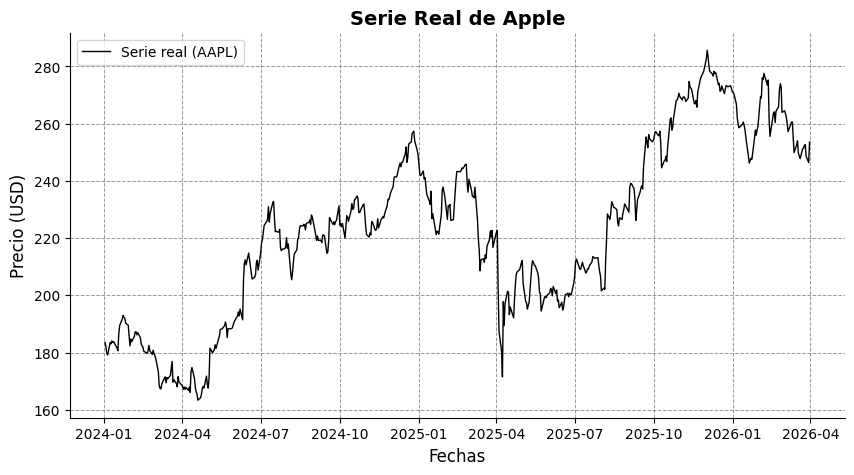

In [ ]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_real,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie real (AAPL)'
)

# # --- Gráfico de línea ---
# # La serie_aproximada aún no ha sido calculada, por lo que se comenta por ahora.
# plt.plot(
#     x, serie_aproximada,
#     color='blue',   # color de la línea
#     linewidth=3.0,        # grosor de la línea
#     linestyle='-',        # estilo de línea
#     marker='o',           # marcador en cada punto
#     markersize=0,         # tamaño del marcador
#     markerfacecolor='white',
#     markeredgecolor='black',
#     label='Serie aproximada (sin ruido)',
#     alpha = 0.5
# )

# --- Título ---
plt.title(
    'Serie Real de Apple',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Precio (USD)',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

In [ ]:
serie_real = y
serie_aproximada = df["tendencia_polinomial"] + df["ruido_polinomial"]

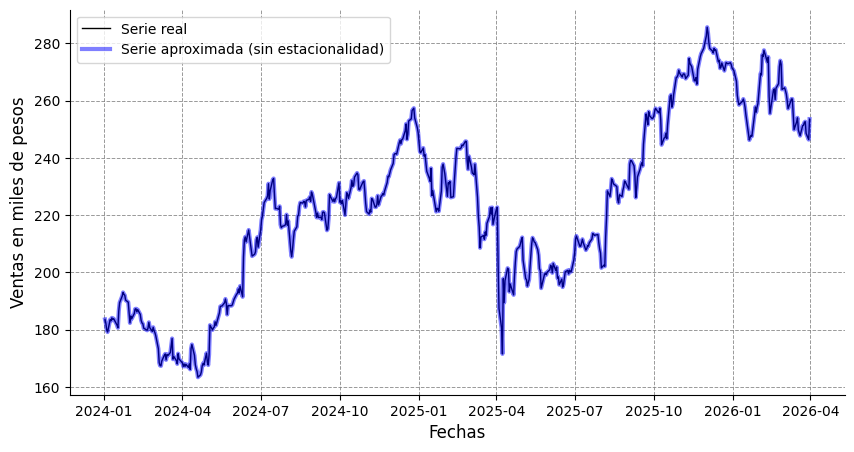

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_real,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie real'
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_aproximada,
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie aproximada (sin estacionalidad)',
    alpha = 0.5
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)


In [ ]:
serie_real = y
serie_aproximada = df["tendencia_polinomial"] + df["ruido_polinomial"]

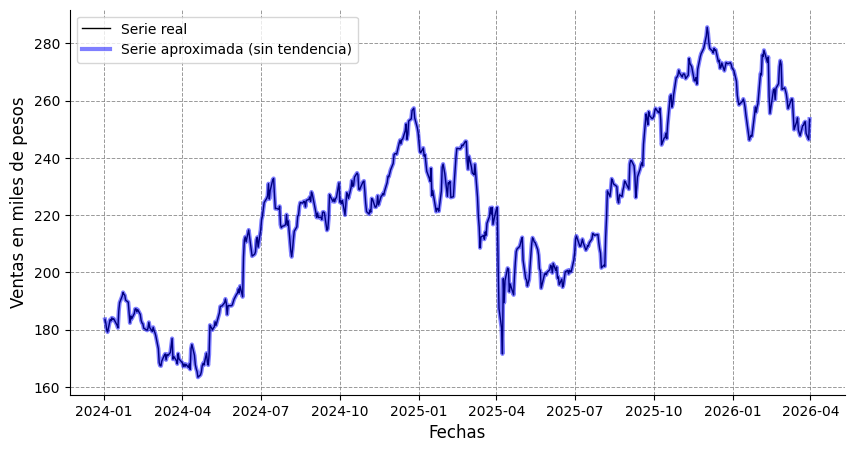

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_real,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie real'
)

# --- Gráfico de línea ---
plt.plot(
    x, serie_aproximada,
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Serie aproximada (sin tendencia)',
    alpha = 0.5
)

# --- Título ---
plt.title(
    '',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Ventas en miles de pesos',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

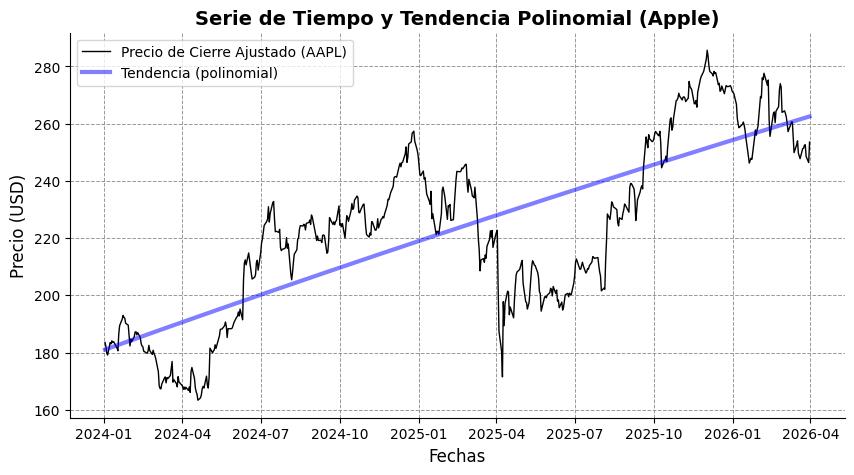

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(10, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=100           # resolución del gráfico
)

# --- Gráfico de línea ---
plt.plot(
    x, y, # Usamos 'y' que es la serie real de Apple
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Precio de Cierre Ajustado (AAPL)'
)

# --- Gráfico de línea ---
plt.plot(
    x, df["tendencia_polinomial"],
    color='blue',   # color de la línea
    linewidth=3.0,        # grosor de la línea
    linestyle='-',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Tendencia (polinomial)',
    alpha = 0.5
)

# --- Gráfico de línea ---
# df["estacionalidad_polinomial"] aún no ha sido calculada, por lo que se comenta por ahora.
# plt.plot(
#     x, df["estacionalidad_polinomial"] + df["ventas"].mean(),
#     color='red',   # color de la línea
#     linewidth=3.0,        # grosor de la línea
#     linestyle='-',        # estilo de línea
#     marker='o',           # marcador en cada punto
#     markersize=0,         # tamaño del marcador
#     markerfacecolor='white',
#     markeredgecolor='black',
#     label='Estacionalidad (polinomial)',
#     alpha = 0.5
# )

# --- Título ---
plt.title(
    'Serie de Tiempo y Tendencia Polinomial (Apple)',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Fechas',
    fontsize=12
)

plt.ylabel(
    'Precio (USD)', # Etiqueta del eje y actualizada para Apple
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.8,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)


**Tendencia**: Muestra la ruta general de crecimiento que ha tenido la acción. Sirve para ver la dirección a largo plazo, pero no para saber qué va a pasar en unos días.

**Estacionalidad**: Casi no se nota en este tipo de datos.

**Ruido**: Es toda la variación del día a día. El modelo sirve para ver la ruta general, pero deja un margen amplio de movimientos imprevistos por la misma naturaleza de la bolsa.  

## Análisis fundamental (ligero)

**Ejercicio 6**: Realiza una interpretación de los componentes de la serie de tiempo (tendencia, estacionalidad y ruido).

En tu análisis:

+ Explica qué factores externos podrían justificar la tendencia observada (por ejemplo: crecimiento de la empresa, cambios en el mercado, decisiones estratégicas, etc.).
+ Identifica posibles eventos o situaciones que expliquen los patrones de estacionalidad.
+ Reflexiona sobre el ruido, indicando qué tipo de eventos inesperados o aleatorios podrían estar representados en este componente.

Este análisis no requiere un estudio exhaustivo del entorno económico, pero sí una interpretación razonada, similar a un análisis fundamental básico.

Una vez termines, borra estas instrucciones y redacta tus observaciones.

**Tendencia:**
El crecimiento sostenido observado en la tendencia se justifica por el desempeño financiero de la empresa, lanzamientos clave de productos, recompras de acciones y la expansión de sus servicios.  
**Estacionalidad:** Aunque no hay un ciclo perfecto, existen repuntes recurrentes en ciertos trimestres (como el último del año), impulsados por las ventas navideñas y las presentaciones de nuevos dispositivos a finales del tercer trimestre.

**Ruido:** Las caídas o subidas abruptas fuera de la línea de tendencia responden a factores externos e imprevistos: reportes trimestrales que no alcanzaron las expectativas, anuncios de tasas de interés por parte de la Reserva Federal, tensiones geopolíticas o ajustes generales en el sector tecnológico.  

## Aplicaciones

**Ejercicio 7**: Analiza qué personas, empresas o instituciones podrían beneficiarse del análisis realizado.

En tu respuesta:

+ Menciona al menos tres actores (por ejemplo: inversionistas, empresas, instituciones financieras, gobierno, etc.).
+ Explica cómo utilizarían este tipo de análisis.
+ Describe qué beneficios concretos podrían obtener.

Adicionalmente, reflexiona sobre cómo un análisis más profundo podría mejorar estos beneficios o ampliar sus aplicaciones.

Relaciona tu respuesta con los resultados obtenidos en tu análisis (tendencia, estacionalidad y ruido).

Una vez termines, borra estas instrucciones y redacta tus observaciones.

**Inversionistas individuales y gestores de fondos:**
Utilizan la tendencia y las medias móviles para identificar puntos de entrada o salida. Les ayuda a no operar por impulso y a definir si la acción está en una fase alcista o de corrección.  
**Instituciones financieras y analistas de riesgo**: Usan el componente de ruido y volatilidad para medir la exposición al riesgo del activo, definir límites de pérdidas (stop-loss) y calcular el valor en riesgo (VaR) de un portafolio.  
**Empresas competidoras o del mismo sector:**
Analizan este comportamiento para evaluar la salud del sector tecnológico, comparar sus retornos contra el referente del mercado y planear decisiones de financiamiento o salida a bolsa.  
**Reflexión:**
Incorporar variables externas (como índices bursátiles generales, tasas de interés o volumen de transacciones) en un modelo más avanzado permitiría reducir el margen de ruido inexplicado y mejorar la precisión de las proyecciones.